In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
##Load Engineered Data
X = np.load("X.npy")
y = np.load("y.npy")

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (7691, 30, 7)
y shape: (7691, 7)


In [3]:
##Train / Validation Split (Temporal)
split = int(0.8 * len(X))

X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Train samples: 6152
Validation samples: 1539


In [4]:
##Define Feature Count
TIMESTEPS = X.shape[1]
FEATURES = X.shape[2]


In [5]:
##LSTM Forecasting Model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(TIMESTEPS, FEATURES)),
    LSTM(32),
    Dense(FEATURES)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()


D:\hyperscale\hyperscale_data_center\ai_models\env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 30, 64)              │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,079 (121.40 KB)

 Trainable params: 31,079 (121.40 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
##Training LSTM Model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0867 - val_loss: 0.0719
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0714 - val_loss: 0.0718
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0713 - val_loss: 0.0718
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0712 - val_loss: 0.0720
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0713 - val_loss: 0.0717
Epoch 6/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0712 - val_loss: 0.0718
Epoch 7/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0711 - val_loss: 0.0721
Epoch 8/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0712 - val_loss: 0.0720
Epoch 9/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0711 - val_loss: 0.0717
Epoch 10/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0712 - val_loss: 0.0718


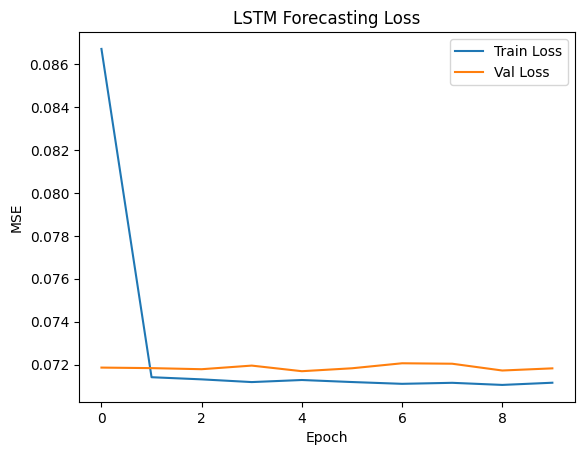

In [7]:
## Plot Training Loss
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("LSTM Forecasting Loss")
plt.legend()
plt.show()


In [8]:
val_loss = lstm_model.evaluate(X_val, y_val, verbose=0)
print("Validation MSE:", val_loss)


Validation MSE: 0.07169418781995773


In [9]:
sample = X_val[-1:]
prediction = lstm_model.predict(sample)

print("Predicted next step:")
print(prediction[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
Predicted next step:
[0.5064285  0.50316054 0.49845403 0.5123813  0.49834493 0.49917117
 0.51756984]


In [10]:
lstm_model.save("lstm_forecasting_model.h5")


In [11]:
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(TIMESTEPS, FEATURES)),
    GRU(32),
    Dense(FEATURES)
])

gru_model.compile(
    optimizer="adam",
    loss="mse"
)

gru_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 30, 64)              │          14,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 32)                  │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,655 (92.40 KB)

 Trainable params: 23,655 (92.40 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - loss: 0.0790 - val_loss: 0.0730
Epoch 2/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0722 - val_loss: 0.0726
Epoch 3/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0718 - val_loss: 0.0723
Epoch 4/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0716 - val_loss: 0.0738
Epoch 5/30
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0716 - val_loss: 0.0721


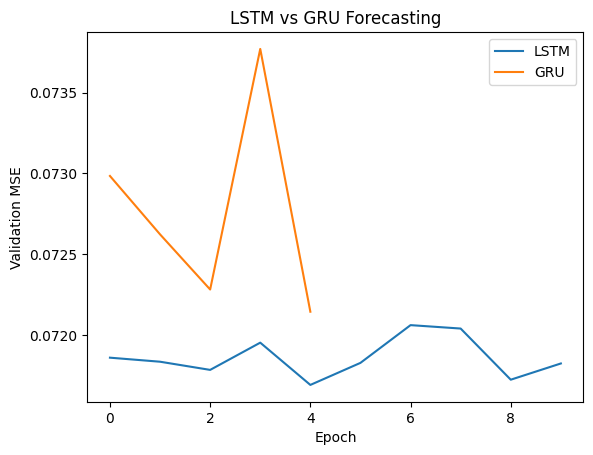

In [13]:
plt.plot(history_lstm.history["val_loss"], label="LSTM")
plt.plot(history_gru.history["val_loss"], label="GRU")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("LSTM vs GRU Forecasting")
plt.legend()
plt.show()


In [14]:
gru_model.save("gru_forecasting_model.h5")


In [15]:
##Multivariate LSTM and GRU models were trained to forecast next-step energy consumption and thermal states of data-center racks using sliding-window telemetry sequences.”